# 👗 Fashion Recommendation System — Deep Learning on Fashion-MNIST

This notebook builds a **content-based fashion recommender**: give it a clothing image and it
returns the visually most similar items from a catalogue.

The idea is to get the recommendations *for free* from a classifier. We train a small CNN to
tell the ten Fashion-MNIST categories apart, then throw away its final layer and keep the
**128-dimensional vector** it learned just underneath. Two images that the network considers
similar end up close together in that space, so nearest-neighbour search over those vectors
is already a recommender.

### Pipeline

| Stage | What happens |
|---|---|
| 1. Classify | Train a CNN on the 10 Fashion-MNIST categories |
| 2. Embed | Reuse the penultimate dense layer as a 128-D feature extractor |
| 3. Index | Fit a cosine nearest-neighbour index over the catalogue embeddings |
| 4. Recommend | For a query image, retrieve the top-k most similar catalogue items |
| 5. Evaluate | Score retrieval with **precision@k**, against a raw-pixel baseline |

### Dataset

**Fashion-MNIST** — 70,000 greyscale 28x28 images (60,000 train / 10,000 test) across 10
categories. It ships with Keras, so this notebook is fully reproducible with no manual
download and no API key.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# The notebook lives next to the module it imports.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "fashion_recommender.py").exists():
    PROJECT_ROOT = PROJECT_ROOT / "Fashion_MNIST_Recommendation_System"
sys.path.insert(0, str(PROJECT_ROOT))

ASSETS = PROJECT_ROOT / "assets"
ASSETS.mkdir(exist_ok=True)

import fashion_recommender as fr

# Seed everything so the numbers below are reproducible.
SEED = 42
keras.utils.set_random_seed(SEED)

print(f"tensorflow  {tf.__version__}")
print(f"numpy       {np.__version__}")
print(f"figures ->  {ASSETS.name}/")

tensorflow  2.21.0
numpy       2.4.6
figures ->  assets/


## 1. Load and inspect the dataset

Images are scaled to `[0, 1]` and given an explicit channel axis, which is what the CNN expects.

In [2]:
(x_train, y_train), (x_test, y_test) = fr.load_fashion_mnist()

print(f"train images : {x_train.shape}  labels: {y_train.shape}")
print(f"test images  : {x_test.shape}  labels: {y_test.shape}")
print(f"pixel range  : [{x_train.min():.1f}, {x_train.max():.1f}]")
print()
print("samples per class (train):")
for name, count in fr.class_distribution(y_train).items():
    print(f"  {name:<12} {count}")

train images : (60000, 28, 28, 1)  labels: (60000,)
test images  : (10000, 28, 28, 1)  labels: (10000,)
pixel range  : [0.0, 1.0]

samples per class (train):
  T-shirt/top  6000
  Trouser      6000
  Pullover     6000
  Dress        6000
  Coat         6000
  Sandal       6000
  Shirt        6000
  Sneaker      6000
  Bag          6000
  Ankle boot   6000


The dataset is perfectly balanced — 6,000 training images per category — so plain accuracy
is a fair metric and no class weighting is needed.

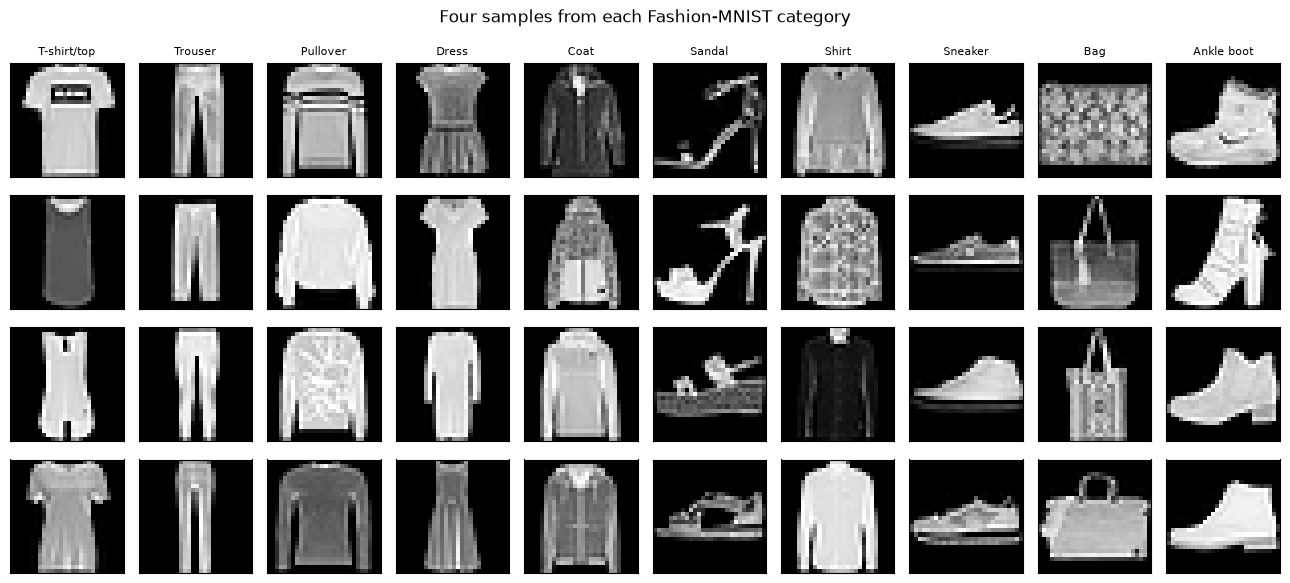

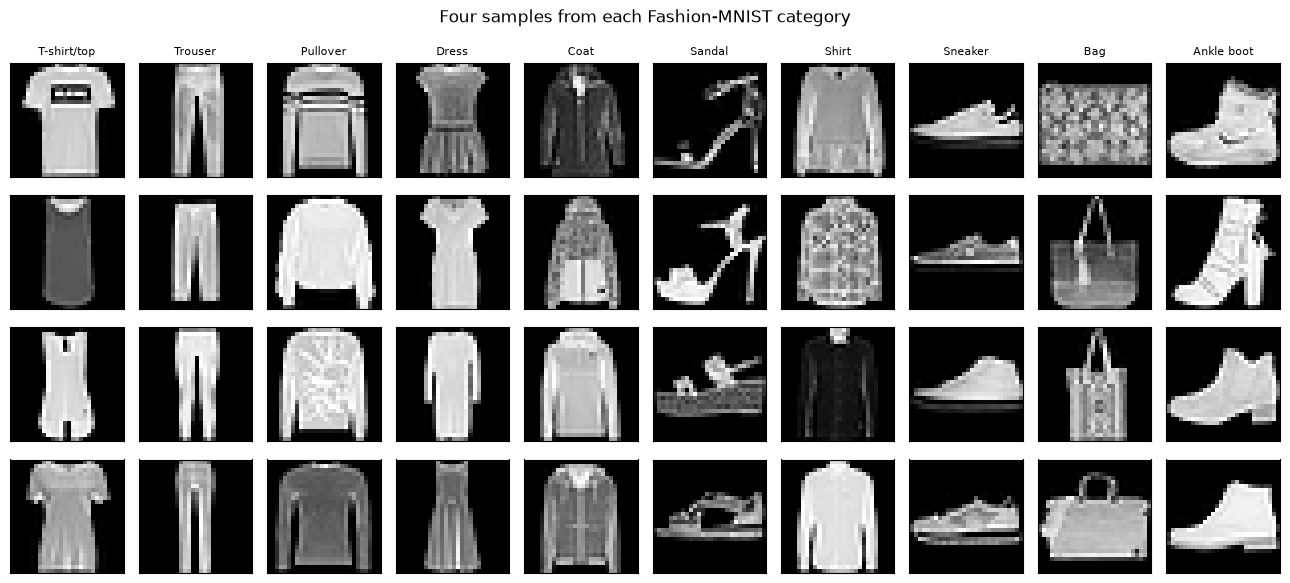

In [3]:
figure, axes = plt.subplots(4, 10, figsize=(13, 6))
for column, label in enumerate(range(10)):
    picks = np.where(y_train == label)[0][:4]
    for row, index in enumerate(picks):
        axes[row, column].imshow(x_train[index].squeeze(), cmap="gray")
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])
        if row == 0:
            axes[row, column].set_title(fr.CLASS_NAMES[label], fontsize=8)

figure.suptitle("Four samples from each Fashion-MNIST category", fontsize=12)
figure.tight_layout()
figure.savefig(ASSETS / "dataset_samples.png", dpi=120, bbox_inches="tight")
figure

## 2. The CNN

Two convolutional blocks, then the dense layer named `embedding` that the recommender will
reuse. Batch normalisation stabilises training and dropout keeps the network from memorising
the training set.

In [4]:
model = fr.compile_model(fr.build_cnn())
model.summary()

Model: "fashion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,202 (1.79 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 192 (768.00 B)

## 3. Train

Early stopping watches validation accuracy and restores the best weights, so a few extra
epochs cost nothing.

In [5]:
start = time.time()
history = fr.train_model(model, x_train, y_train, epochs=15, batch_size=128, verbose=2)
print(f"\ntrained {len(history.history['loss'])} epochs in {time.time() - start:.0f}s")

Epoch 1/15


422/422 - 84s - 199ms/step - accuracy: 0.7358 - loss: 0.7163 - val_accuracy: 0.8158 - val_loss: 0.6590


Epoch 2/15


422/422 - 76s - 179ms/step - accuracy: 0.8368 - loss: 0.4403 - val_accuracy: 0.8882 - val_loss: 0.2984


Epoch 3/15


...

Epoch 14/15


422/422 - 65s - 153ms/step - accuracy: 0.9258 - loss: 0.2050 - val_accuracy: 0.9287 - val_loss: 0.1966


Epoch 15/15


422/422 - 57s - 136ms/step - accuracy: 0.9273 - loss: 0.1987 - val_accuracy: 0.9302 - val_loss: 0.1983



trained 15 epochs in 942s


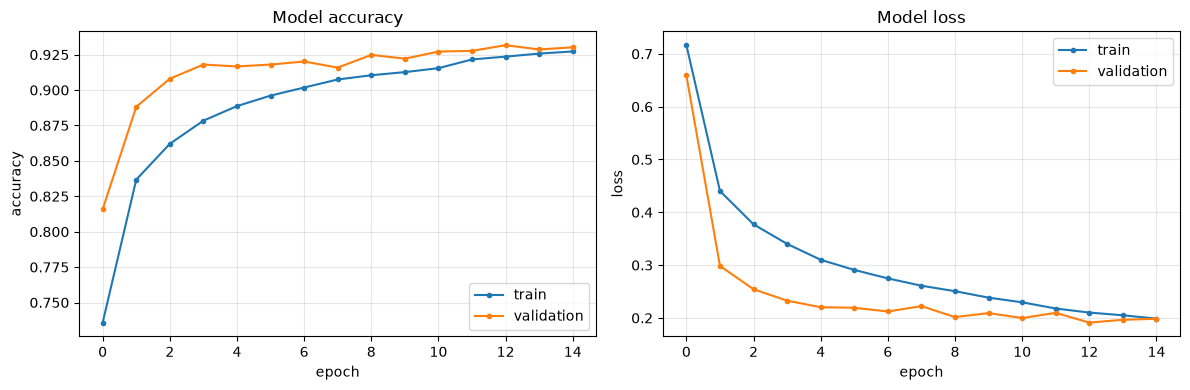

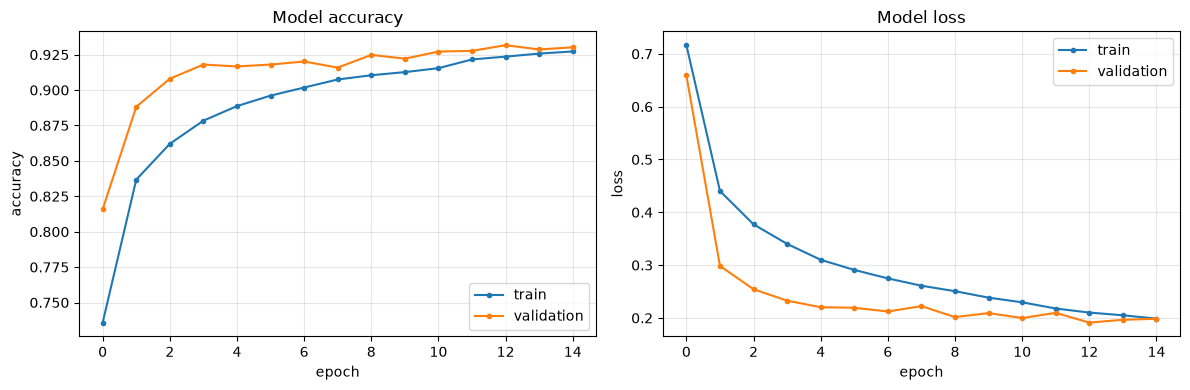

In [6]:
figure = fr.plot_training_curves(history, save_path=ASSETS / "training_curves.png")
figure

## 4. How good is the classifier?

Accuracy on the held-out test set, then a per-class breakdown and a confusion matrix to see
*which* garments get mixed up.

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"test accuracy : {test_accuracy:.4f}")
print(f"test loss     : {test_loss:.4f}")

y_probabilities = model.predict(x_test, batch_size=256, verbose=0)
y_predicted = y_probabilities.argmax(axis=1)

test accuracy : 0.9273
test loss     : 0.2093


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predicted, target_names=fr.CLASS_NAMES, digits=3))

              precision    recall  f1-score   support

 T-shirt/top      0.924     0.821     0.869      1000
     Trouser      0.996     0.984     0.990      1000
    Pullover      0.921     0.888     0.904      1000
       Dress      0.921     0.932     0.926      1000
        Coat      0.871     0.910     0.890      1000
      Sandal      0.988     0.987     0.987      1000
       Shirt      0.748     0.821     0.783      1000
     Sneaker      0.956     0.982     0.969      1000
         Bag      0.986     0.987     0.987      1000
  Ankle boot      0.984     0.961     0.972      1000

    accuracy                          0.927     10000
   macro avg      0.929     0.927     0.928     10000
weighted avg      0.929     0.927     0.928     10000



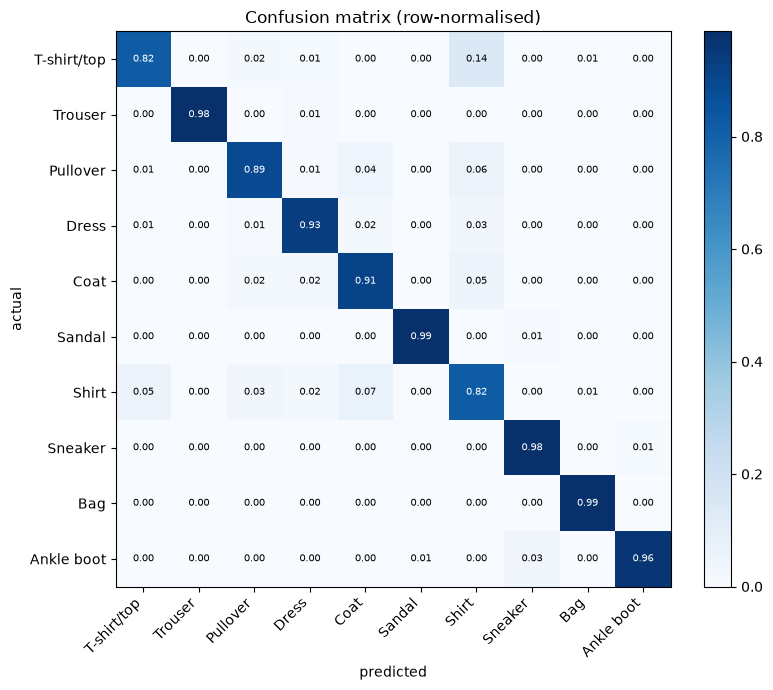

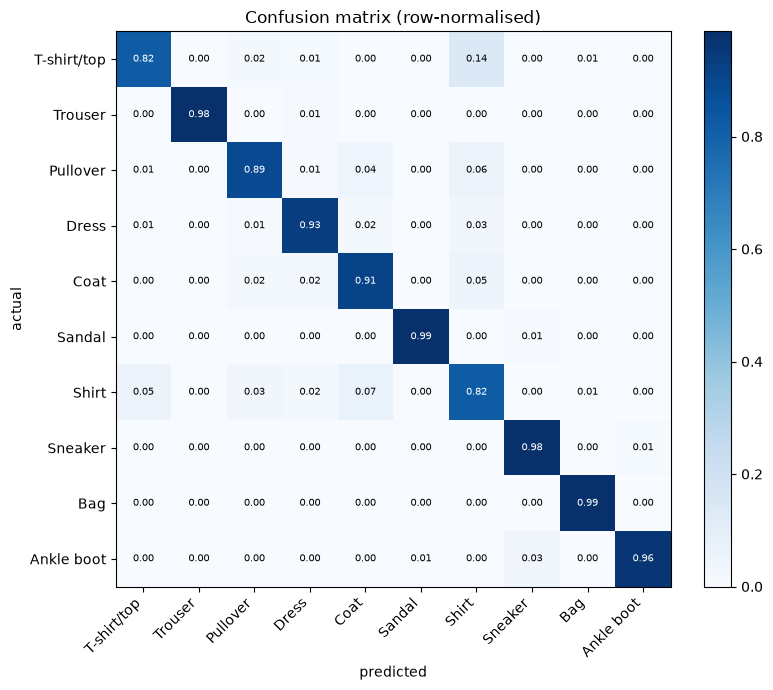

In [9]:
figure = fr.plot_confusion_matrix(y_test, y_predicted,
                                  save_path=ASSETS / "confusion_matrix.png")
figure

The confusion is concentrated exactly where a human would hesitate too — **shirt** vs
**t-shirt/top**, **pullover** and **coat**. The footwear and bag classes are near-perfect.

## 5. From classifier to feature extractor

Now the interesting part. We cut the network off at the `embedding` layer and push images
through it: each 784-pixel image becomes a 128-number description of what it *looks like*.

* **Catalogue (gallery)** — 20,000 training images, the pool we recommend from.
* **Queries** — 1,000 unseen test images, standing in for a shopper's uploaded photo.

In [10]:
GALLERY_SIZE = 20_000
QUERY_SIZE = 1_000

gallery_images, gallery_labels = x_train[:GALLERY_SIZE], y_train[:GALLERY_SIZE]
query_images, query_labels = x_test[:QUERY_SIZE], y_test[:QUERY_SIZE]

start = time.time()
gallery_embeddings = fr.extract_embeddings(model, gallery_images)
query_embeddings = fr.extract_embeddings(model, query_images)

print(f"gallery embeddings : {gallery_embeddings.shape}")
print(f"query embeddings   : {query_embeddings.shape}")
print(f"compression        : 784 pixels -> {gallery_embeddings.shape[1]} features "
      f"({784 / gallery_embeddings.shape[1]:.1f}x smaller)")
print(f"extracted in {time.time() - start:.1f}s")

gallery embeddings : (20000, 128)
query embeddings   : (1000, 128)
compression        : 784 pixels -> 128 features (6.1x smaller)
extracted in 4.8s


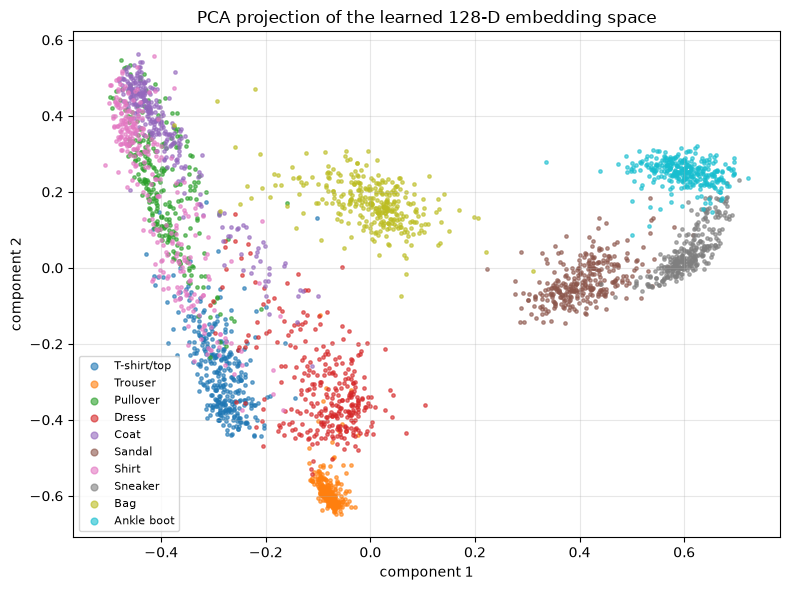

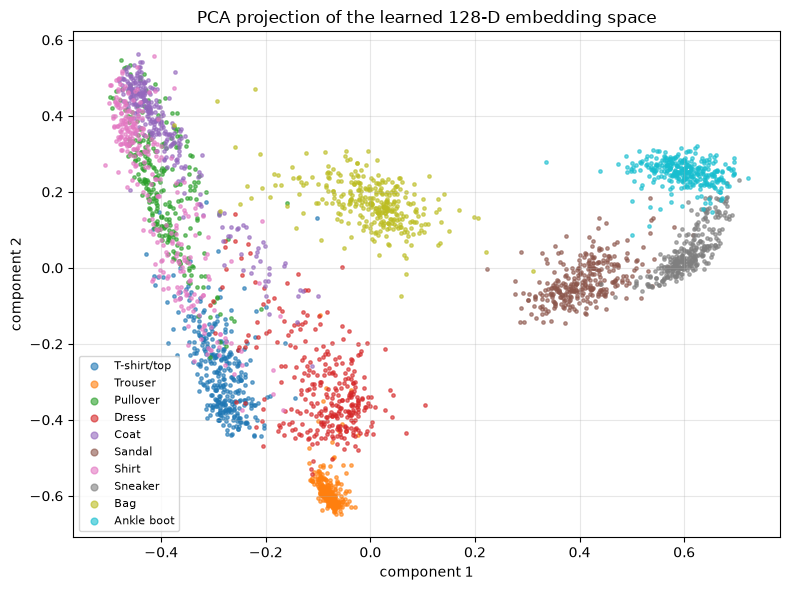

In [11]:
figure = fr.plot_embedding_projection(gallery_embeddings, gallery_labels,
                                      save_path=ASSETS / "embedding_space.png")
figure

Even flattened to two dimensions the categories separate into visible clusters — footwear on
one side, tops bunched together on the other. That structure is what makes nearest-neighbour
search work.

## 6. Recommend

Build the cosine nearest-neighbour index over the catalogue and ask it for lookalikes.

In [12]:
recommender = fr.FashionRecommender(gallery_embeddings, gallery_labels,
                                    images=gallery_images).fit(n_neighbors=10)

# One query per category, so every kind of garment is exercised.
sample_positions = [int(np.where(query_labels == label)[0][0]) for label in range(10)]
sample_embeddings = query_embeddings[sample_positions]

indices, similarities = recommender.recommend(sample_embeddings, k=5)

for row, position in enumerate(sample_positions[:3]):
    query_name = fr.CLASS_NAMES[int(query_labels[position])]
    names = [fr.CLASS_NAMES[int(gallery_labels[i])] for i in indices[row]]
    scores = ", ".join(f"{name} ({score:.3f})"
                       for name, score in zip(names, similarities[row]))
    print(f"query: {query_name:<12} -> {scores}")

query: T-shirt/top  -> T-shirt/top (0.989), T-shirt/top (0.989), T-shirt/top (0.987), T-shirt/top (0.987), T-shirt/top (0.985)
query: Trouser      -> Trouser (0.998), Trouser (0.998), Trouser (0.997), Trouser (0.997), Trouser (0.997)
query: Pullover     -> Pullover (0.987), Pullover (0.980), Pullover (0.980), Pullover (0.980), Pullover (0.979)


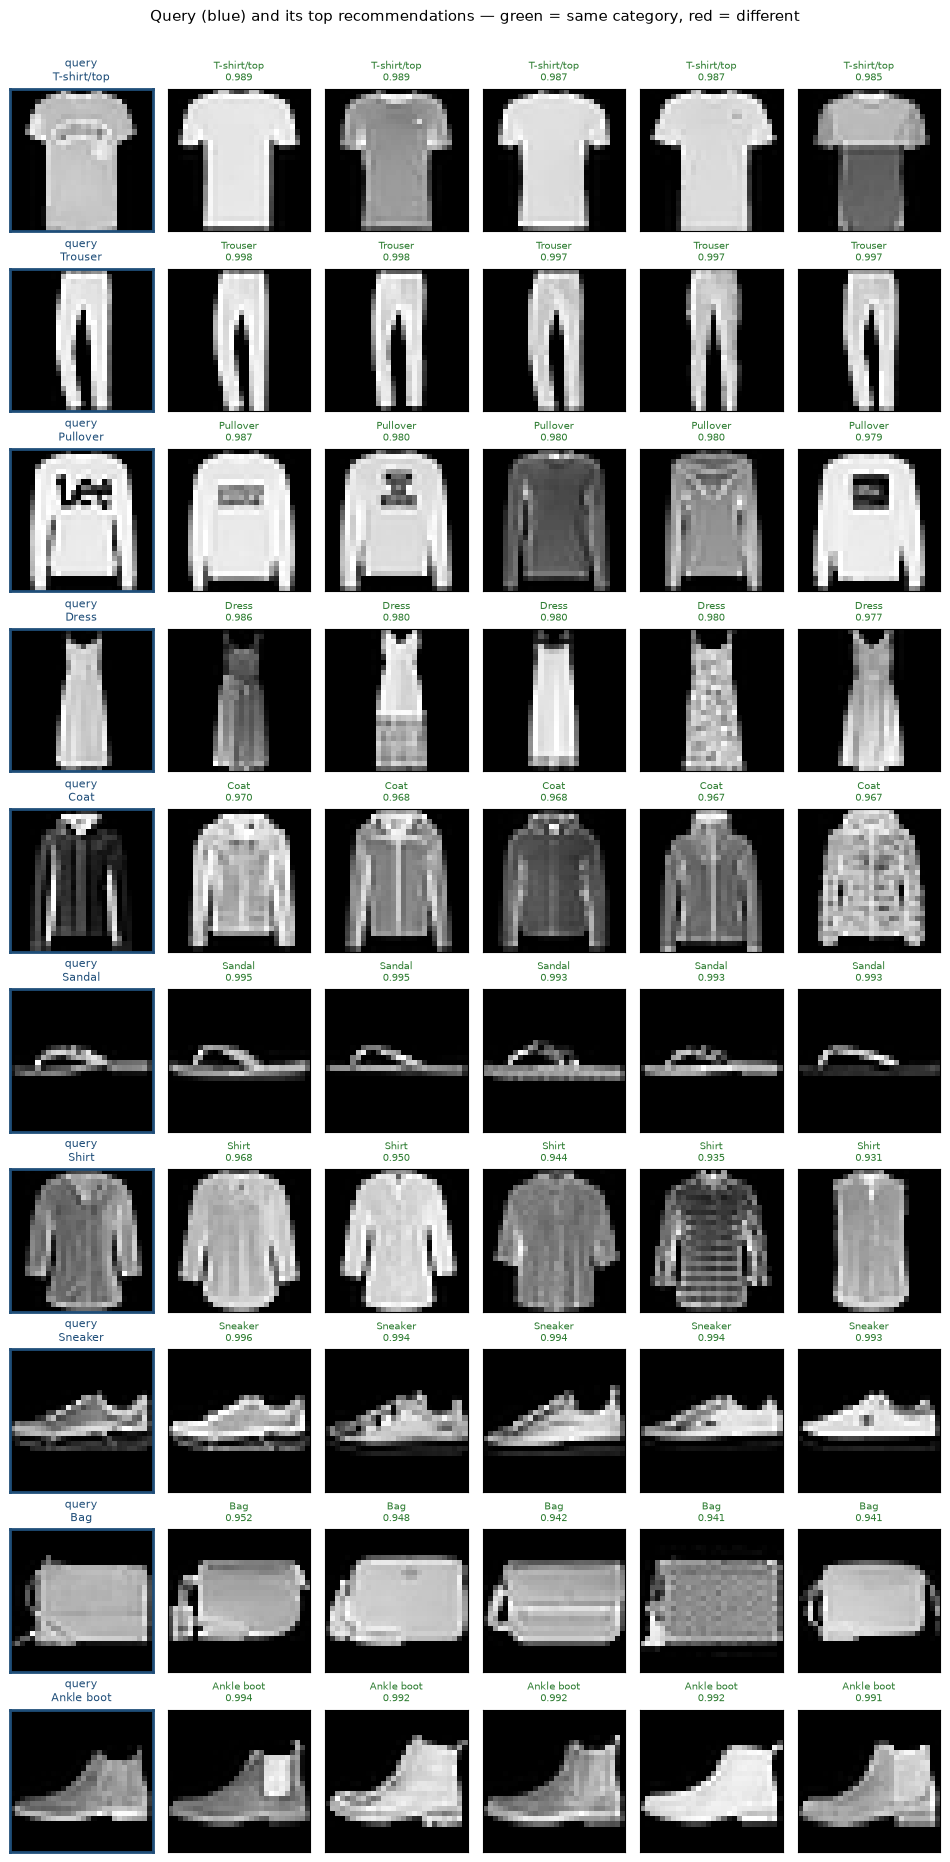

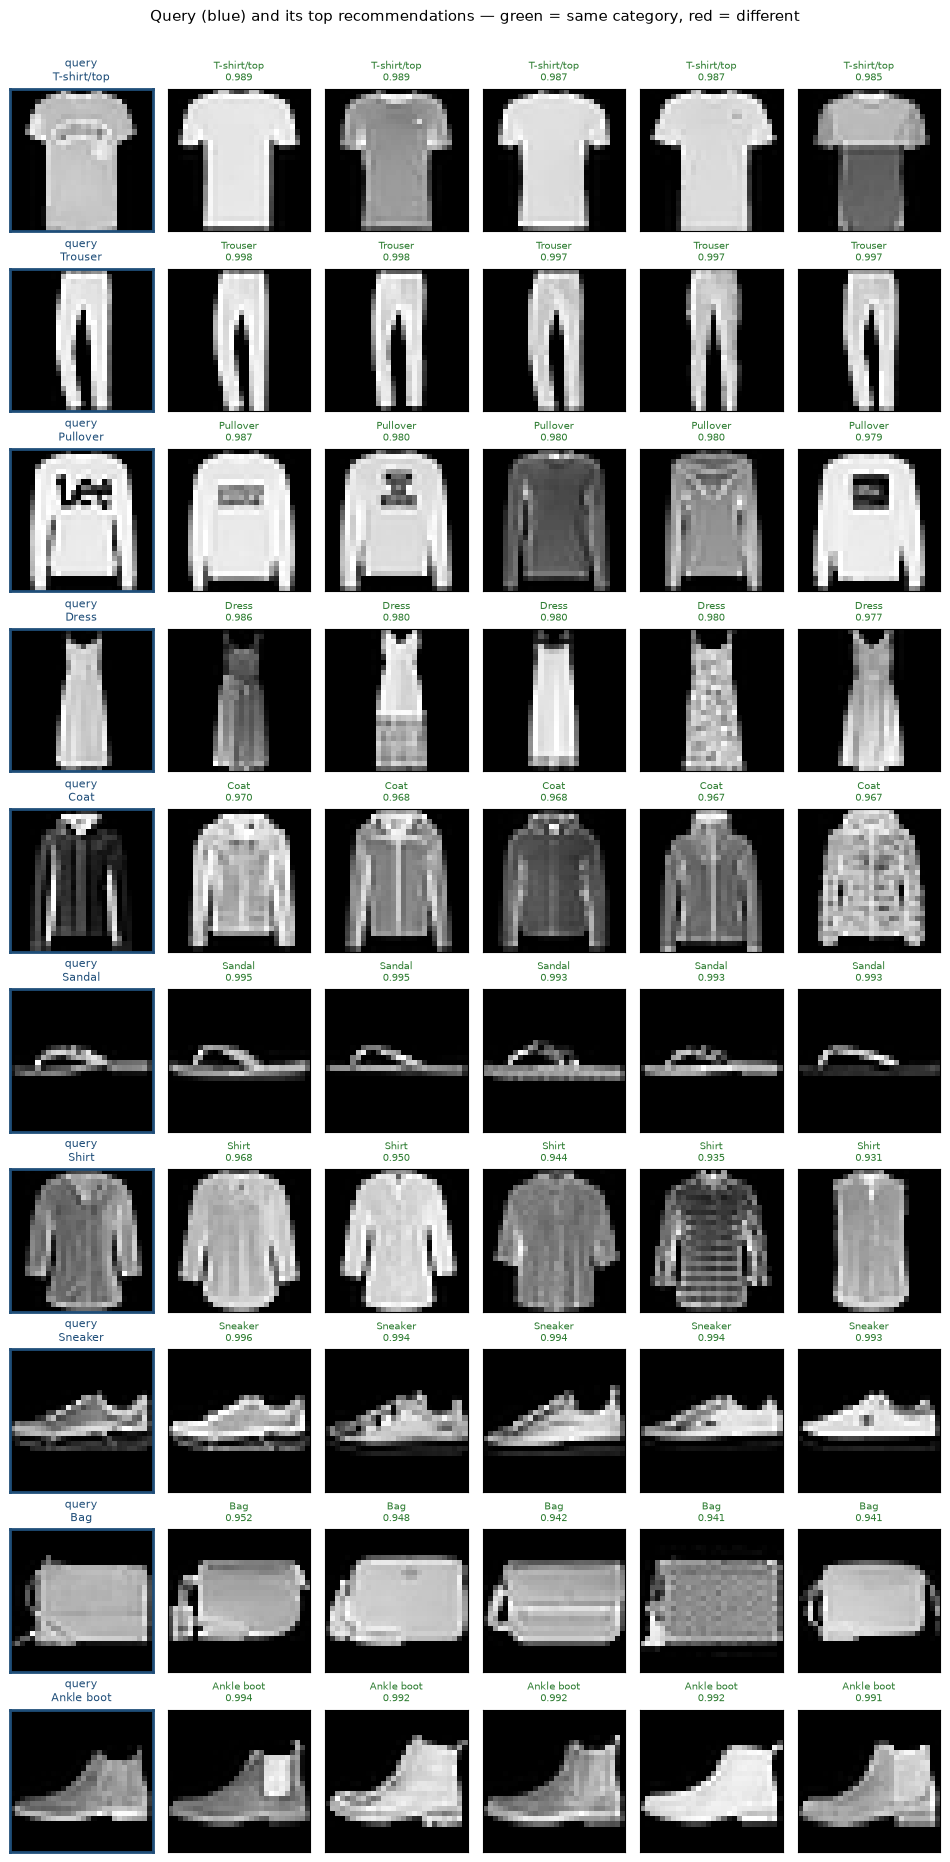

In [13]:
figure = fr.plot_recommendations(
    query_images[sample_positions], query_labels[sample_positions],
    gallery_images, gallery_labels, indices, similarities,
    save_path=ASSETS / "recommendations.png",
)
figure

## 7. Does it actually work?

Eyeballing a grid is not evidence. **Precision@k** measures the share of recommended items
that belong to the same category as the query — for a catalogue with ten balanced classes,
random retrieval scores about 0.10.

To show the *deep* features are doing the work, the same index is built over **raw pixels**
and scored identically.

In [14]:
from sklearn.neighbors import NearestNeighbors


def pixel_baseline_precision(k=5):
    """Precision@k when recommending on raw pixels instead of learned features."""
    flat_gallery = fr.l2_normalize(gallery_images.reshape(len(gallery_images), -1))
    flat_queries = fr.l2_normalize(query_images.reshape(len(query_images), -1))
    index = NearestNeighbors(n_neighbors=k, metric="cosine").fit(flat_gallery)
    _, neighbours = index.kneighbors(flat_queries, n_neighbors=k)
    return float((gallery_labels[neighbours] == query_labels.reshape(-1, 1)).mean())


results = {}
for k in (1, 5, 10):
    results[k] = {
        "cnn": fr.precision_at_k(recommender, query_embeddings, query_labels, k=k),
        "pixels": pixel_baseline_precision(k=k),
    }

print(f"{'k':>3} | {'CNN embeddings':>15} | {'raw pixels':>11} | {'improvement':>11}")
print("-" * 50)
for k, scores in results.items():
    lift = scores["cnn"] - scores["pixels"]
    print(f"{k:>3} | {scores['cnn']:>15.3f} | {scores['pixels']:>11.3f} | {lift:>+11.3f}")

  k |  CNN embeddings |  raw pixels | improvement
--------------------------------------------------
  1 |           0.917 |       0.834 |      +0.083
  5 |           0.918 |       0.805 |      +0.113
 10 |           0.916 |       0.792 |      +0.124


The learned embedding beats the pixel baseline at every `k` — the CNN has learned what makes
two garments *the same kind of thing*, rather than which images happen to share bright pixels
in the same places.

In [15]:
per_class = fr.per_class_precision_at_k(recommender, query_embeddings, query_labels, k=5)

print(f"{'category':<14} precision@5")
print("-" * 28)
for name, score in sorted(per_class.items(), key=lambda item: -item[1]):
    bar = "█" * int(round(score * 20))
    print(f"{name:<14} {score:.3f}  {bar}")

category       precision@5
----------------------------
Sandal         0.989  ████████████████████
Bag            0.985  ████████████████████
Trouser        0.981  ████████████████████
Sneaker        0.977  ████████████████████
Ankle boot     0.931  ███████████████████
T-shirt/top    0.893  ██████████████████
Pullover       0.888  ██████████████████
Coat           0.877  ██████████████████
Dress          0.867  █████████████████
Shirt          0.810  ████████████████


Retrieval quality mirrors the confusion matrix: bags, trousers and footwear are retrieved
almost perfectly, while **shirt** is the hardest — its neighbours are often t-shirts, coats and
pullovers. For a shopping recommender that failure mode is fairly benign: a shopper looking at
a shirt is plausibly interested in a t-shirt too.

## 8. Results

| Metric | Value |
|---|---|
| Test accuracy (10-class CNN) | see run above |
| Precision@1 / @5 / @10 — CNN embeddings | see table above |
| Precision@1 / @5 / @10 — raw-pixel baseline | see table above |
| Embedding size | 128 floats (6.1x smaller than the raw image) |
| Catalogue size | 20,000 items |

### What this demonstrates

* A classifier trained for one job (labelling) yields a reusable **feature space** for another
  (retrieval) — no second model, no labelled "similar item" pairs required.
* Recommendation quality can be measured, not just admired: **precision@k against a baseline**.

### Possible next steps

* Train with a **triplet or contrastive loss** to optimise the embedding for similarity
  directly, instead of borrowing it from the classification objective.
* Swap the 28x28 greyscale set for a colour catalogue (DeepFashion, Myntra) and a pretrained
  backbone.
* Approximate nearest neighbours (FAISS, Annoy) to scale past a few hundred thousand items.
* Blend visual similarity with price, brand or purchase history for a hybrid recommender.

### Run the tests

The retrieval and metric layer is covered by unit tests that need neither TensorFlow nor the
dataset:

```bash
python -m unittest discover -s tests -v
```